In [ ]:
!python -m pip install --upgrade pip

!pip install tensorflow==2.3.1
!pip install tensorboard==2.4.1

!pip install torch  #YOLOv5 runs on top of PyTorch, so we need to import it to the notebook

In [2]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [3]:
!ln -s /content/gdrive/My\ Drive/ /mydrive

In [4]:
%cd /mydrive/Deep_Learning/Plants/Blur-Clear

/content/gdrive/My Drive/Deep_Learning/Plants/Blur-Clear


In [5]:
!pwd

/content/gdrive/My Drive/Deep_Learning/Plants/Blur-Clear


In [6]:
import torch # YOLOv5 implemented using pytorch

In [7]:
from IPython.display import Image #this is to render predictions

In [ ]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 16094, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 16094 (delta 0), reused 3 (delta 0), pack-reused 16089
Receiving objects: 100% (16094/16094), 14.82 MiB | 14.61 MiB/s, done.
Resolving deltas: 100% (11023/11023), done.


In [ ]:
!pip install -r requirements.txt

In [ ]:
# Downloaded the dataset from internet to execute this example

# download custom data of common traffic signs

# !wget --no-check-certificate "https://onedrive.live.com/download?cid=A86CBC7F31A1C06B&resid=A86CBC7F31A1C06B%21121&authkey=AMUUk0Np4tqH3n4" -O ts.zip
# !unzip ts.zip
# !rm -f ts.zip

In [ ]:
import os
from random import choice
import shutil

#arrays to store file names
imgs =[]
xmls =[]

#setup dir names
# trainPath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/images/train'
valPath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/images/val'
crsPath = '/mydrive/Deep_Learning/Plants/Blur-Clear/data/ts/' #dir where images and annotations stored

#setup ratio (val ratio = rest of the files in origin dir after splitting into train and test)
train_ratio = 0.8
val_ratio = 0.2


#total count of imgs
totalImgCount = len(os.listdir(crsPath))/2

#soring files to corresponding arrays
for (dirname, dirs, files) in os.walk(crsPath):
    for filename in files:
        if filename.endswith('.txt'):
            xmls.append(filename)
        else:
            imgs.append(filename)


#counting range for cycles
countForTrain = int(len(imgs)*train_ratio)
countForVal = int(len(imgs)*val_ratio)
print("training images are : ",countForTrain)
print("Validation images are : ",countForVal)

training images are :  13
Validation images are :  3


In [ ]:
trainimagePath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/images/train'
trainlabelPath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/labels/train'
valimagePath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/images/val'
vallabelPath = '/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/labels/val'

#cycle for train dir
for x in range(countForTrain):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    #shutil.move(os.path.join(crsPath, fileJpg), os.path.join(trainimagePath, fileJpg))
    #shutil.move(os.path.join(crsPath, fileXml), os.path.join(trainlabelPath, fileXml))
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(trainimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(trainlabelPath, fileXml))


    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)



#cycle for test dir
for x in range(countForVal):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    #shutil.move(os.path.join(crsPath, fileJpg), os.path.join(valimagePath, fileJpg))
    #shutil.move(os.path.join(crsPath, fileXml), os.path.join(vallabelPath, fileXml))
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(valimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(vallabelPath, fileXml))

    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)

#rest of files will be validation files, so rename origin dir to val dir
#os.rename(crsPath, valPath)
shutil.move(crsPath, valPath)

'/mydrive/Deep_Learning/Plants/Blur-Clear/dataset/images/val/ts'

In [8]:
%cd yolov5

/content/gdrive/MyDrive/Deep_Learning/Plants/Blur-Clear/yolov5


In [9]:
%pwd

'/content/gdrive/MyDrive/Deep_Learning/Plants/Blur-Clear/yolov5'

In [ ]:
!python train.py --img 415 --batch 16 --epochs 100 --data dataset.yaml --weights yolov5s.pt --cache

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.4/660.4 kB 12.9 MB/s eta 0:00:00
2023-12-11 18:18:35.337504: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-11 18:18:35.337570: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-11 18:18:35.337615: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
requirements: Ultralytics requirement ['gitpython'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 273.4 MB/s eta 0:00:00

requirements: AutoUpdate success

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

In [ ]:
!pwd

/content/gdrive/MyDrive/Deep_Learning/Plants/Blur-Clear/yolov5


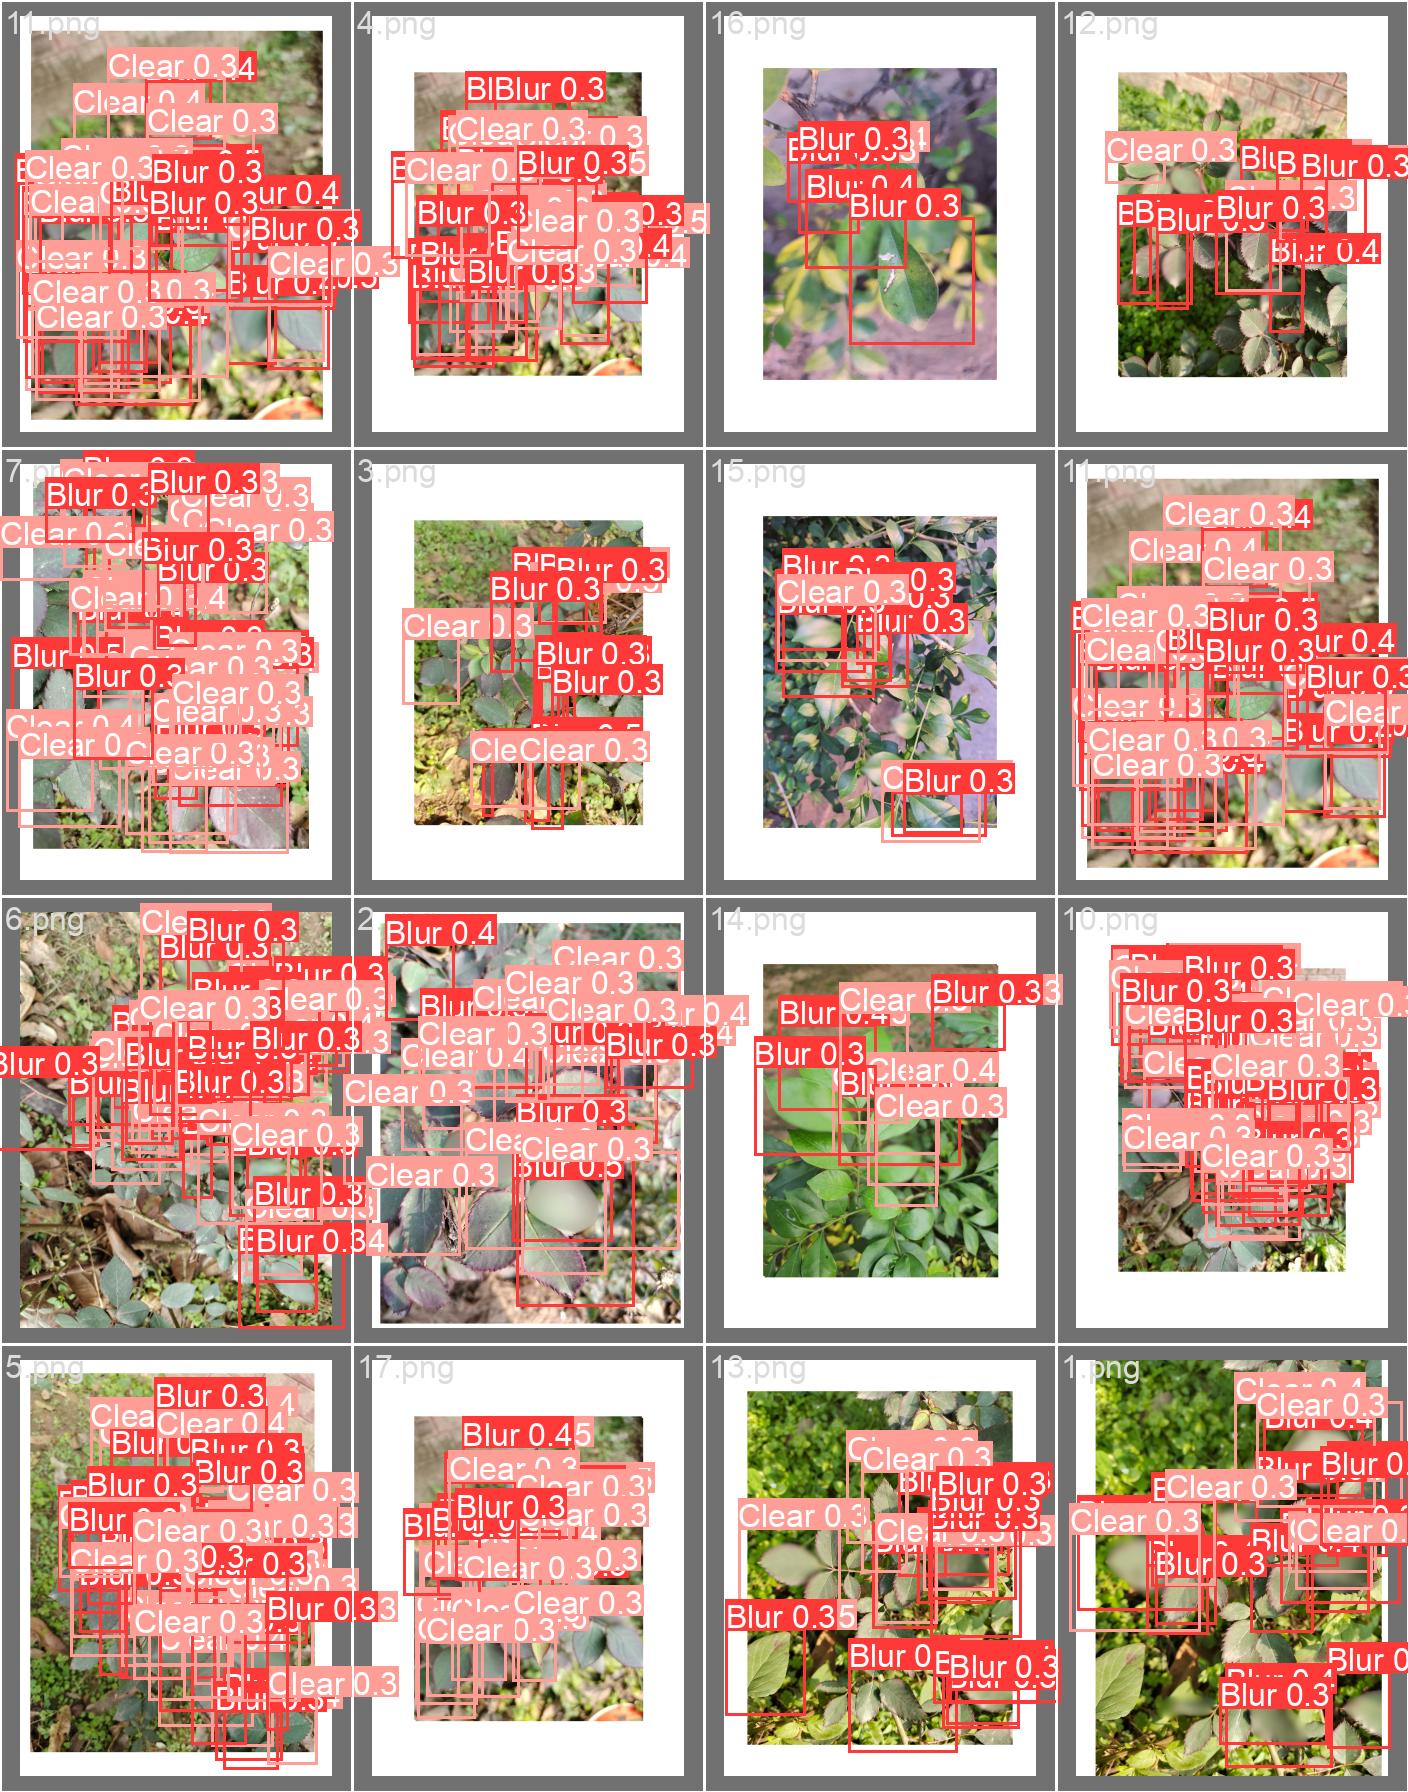

In [13]:
Image(filename='runs/train/exp/val_batch0_pred.jpg', width=700)

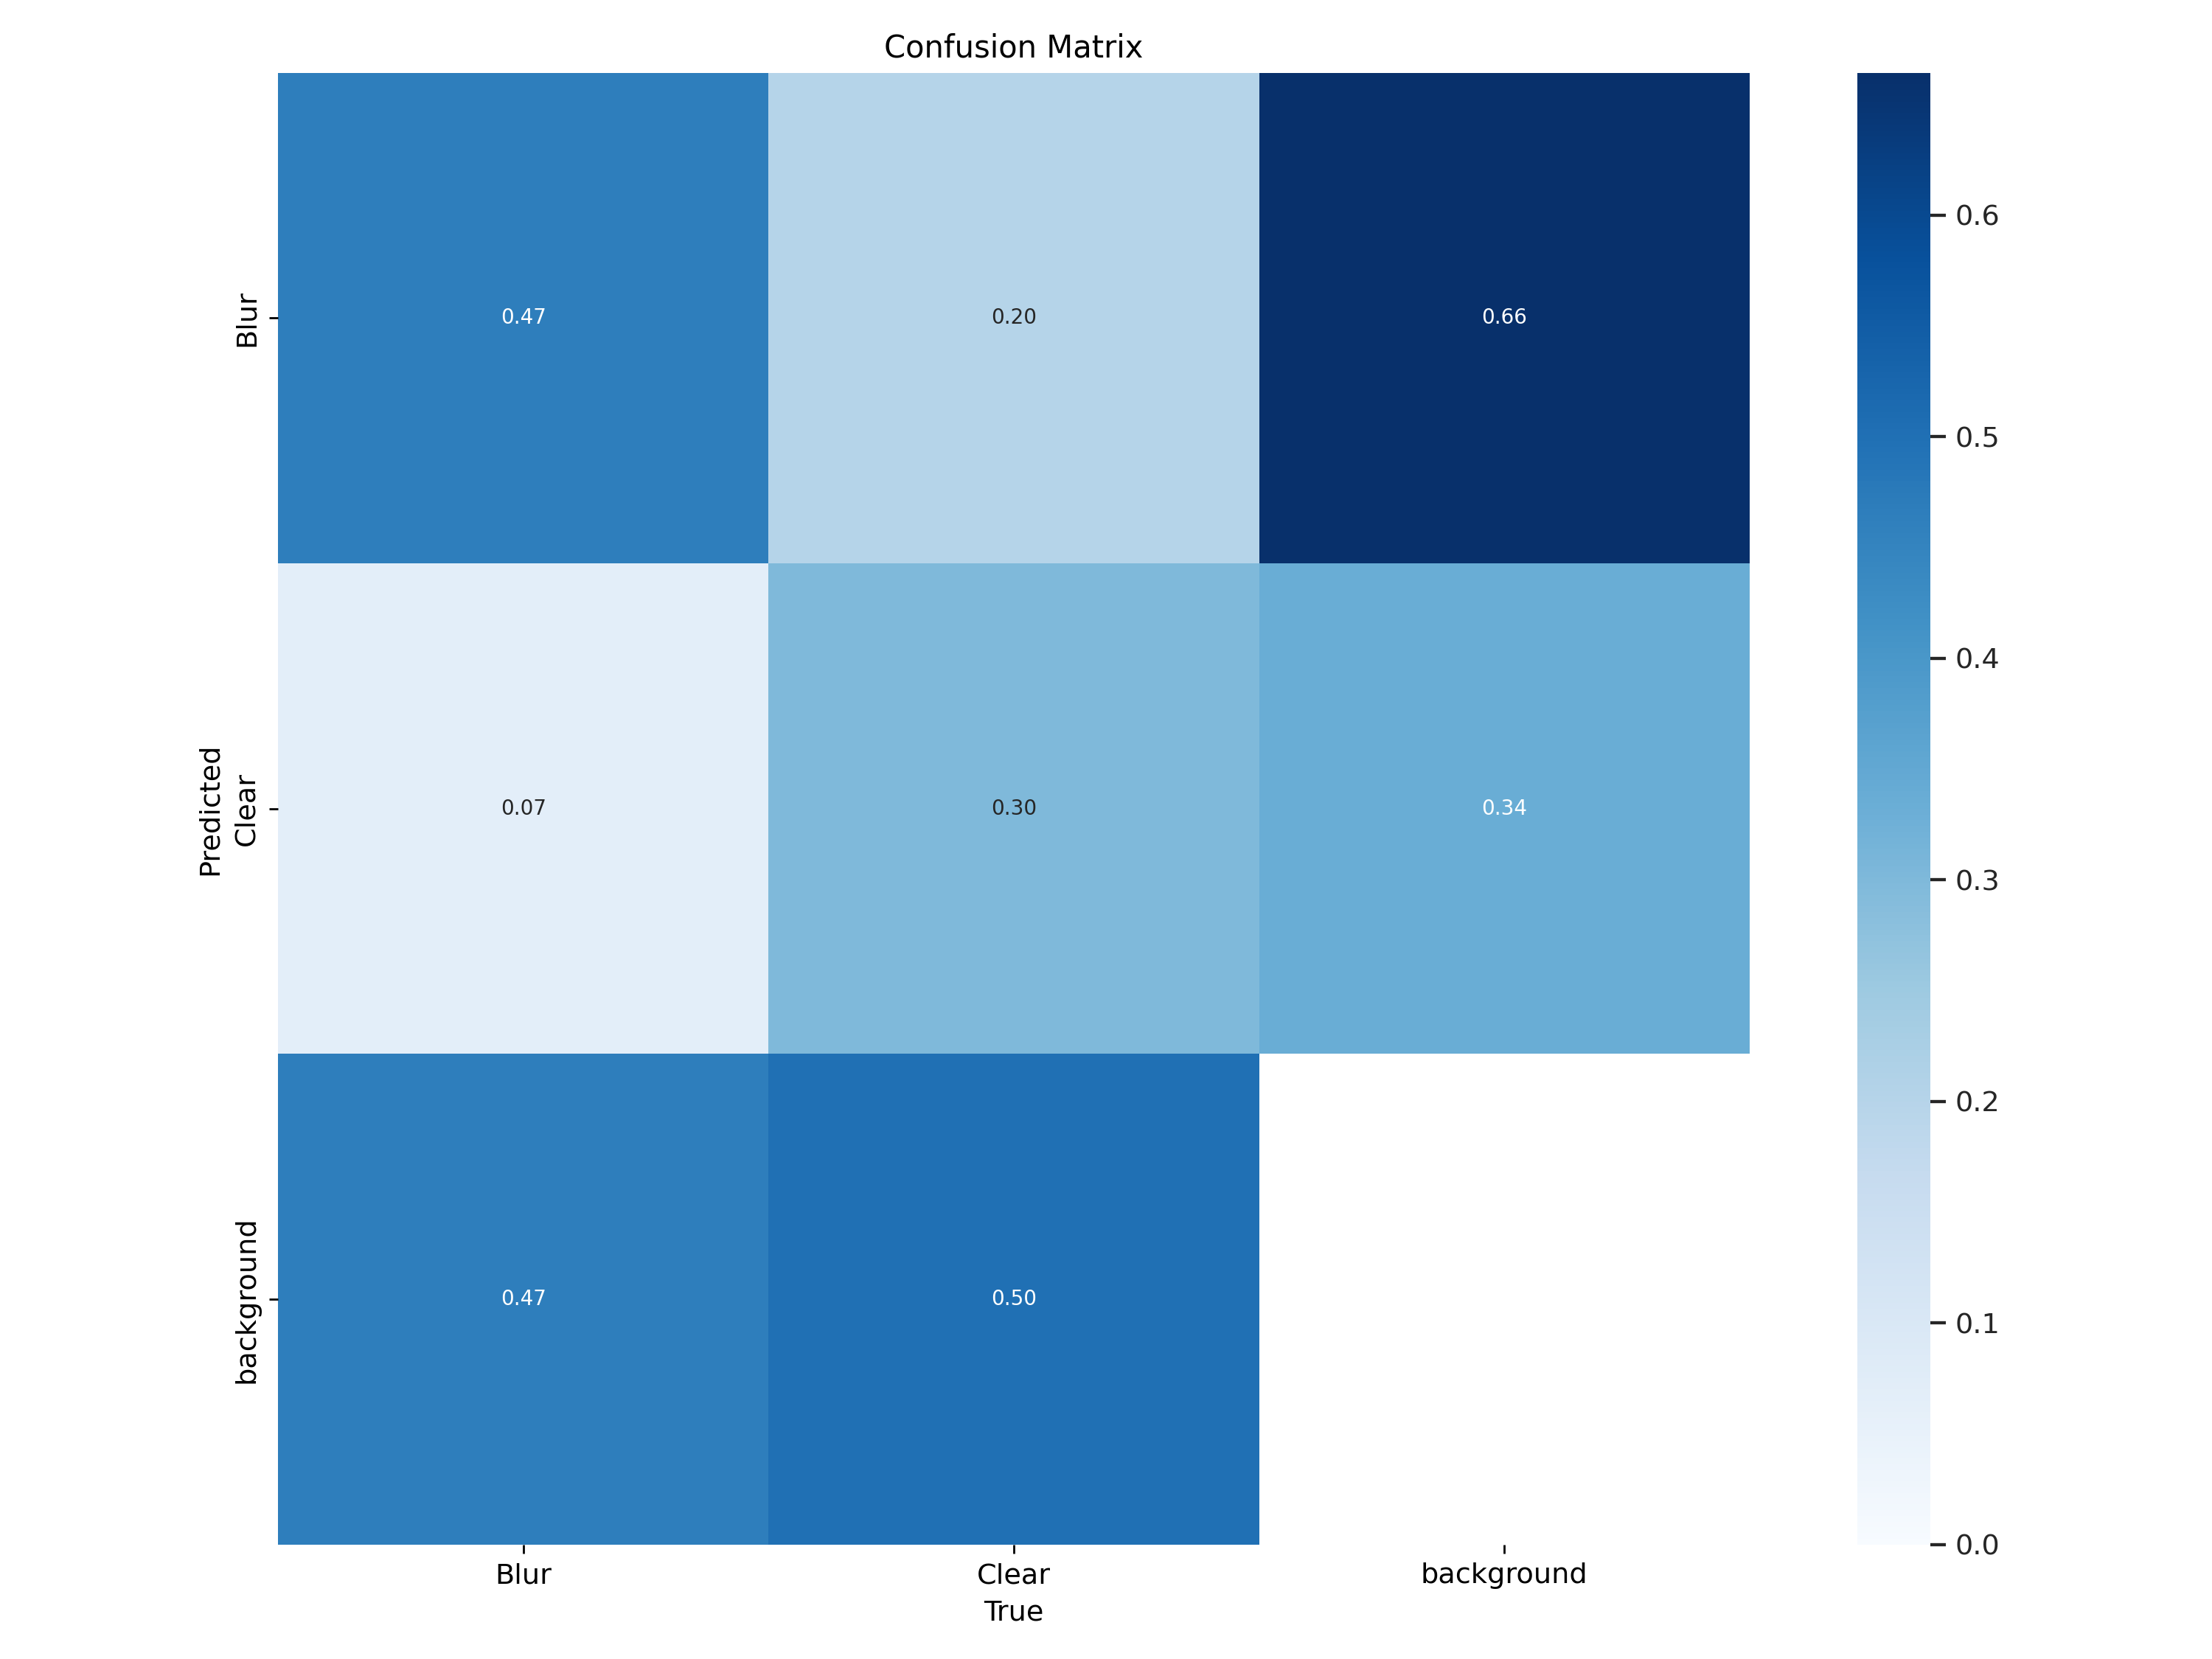

In [14]:
Image(filename='runs/val/exp/confusion_matrix.png', width=800)

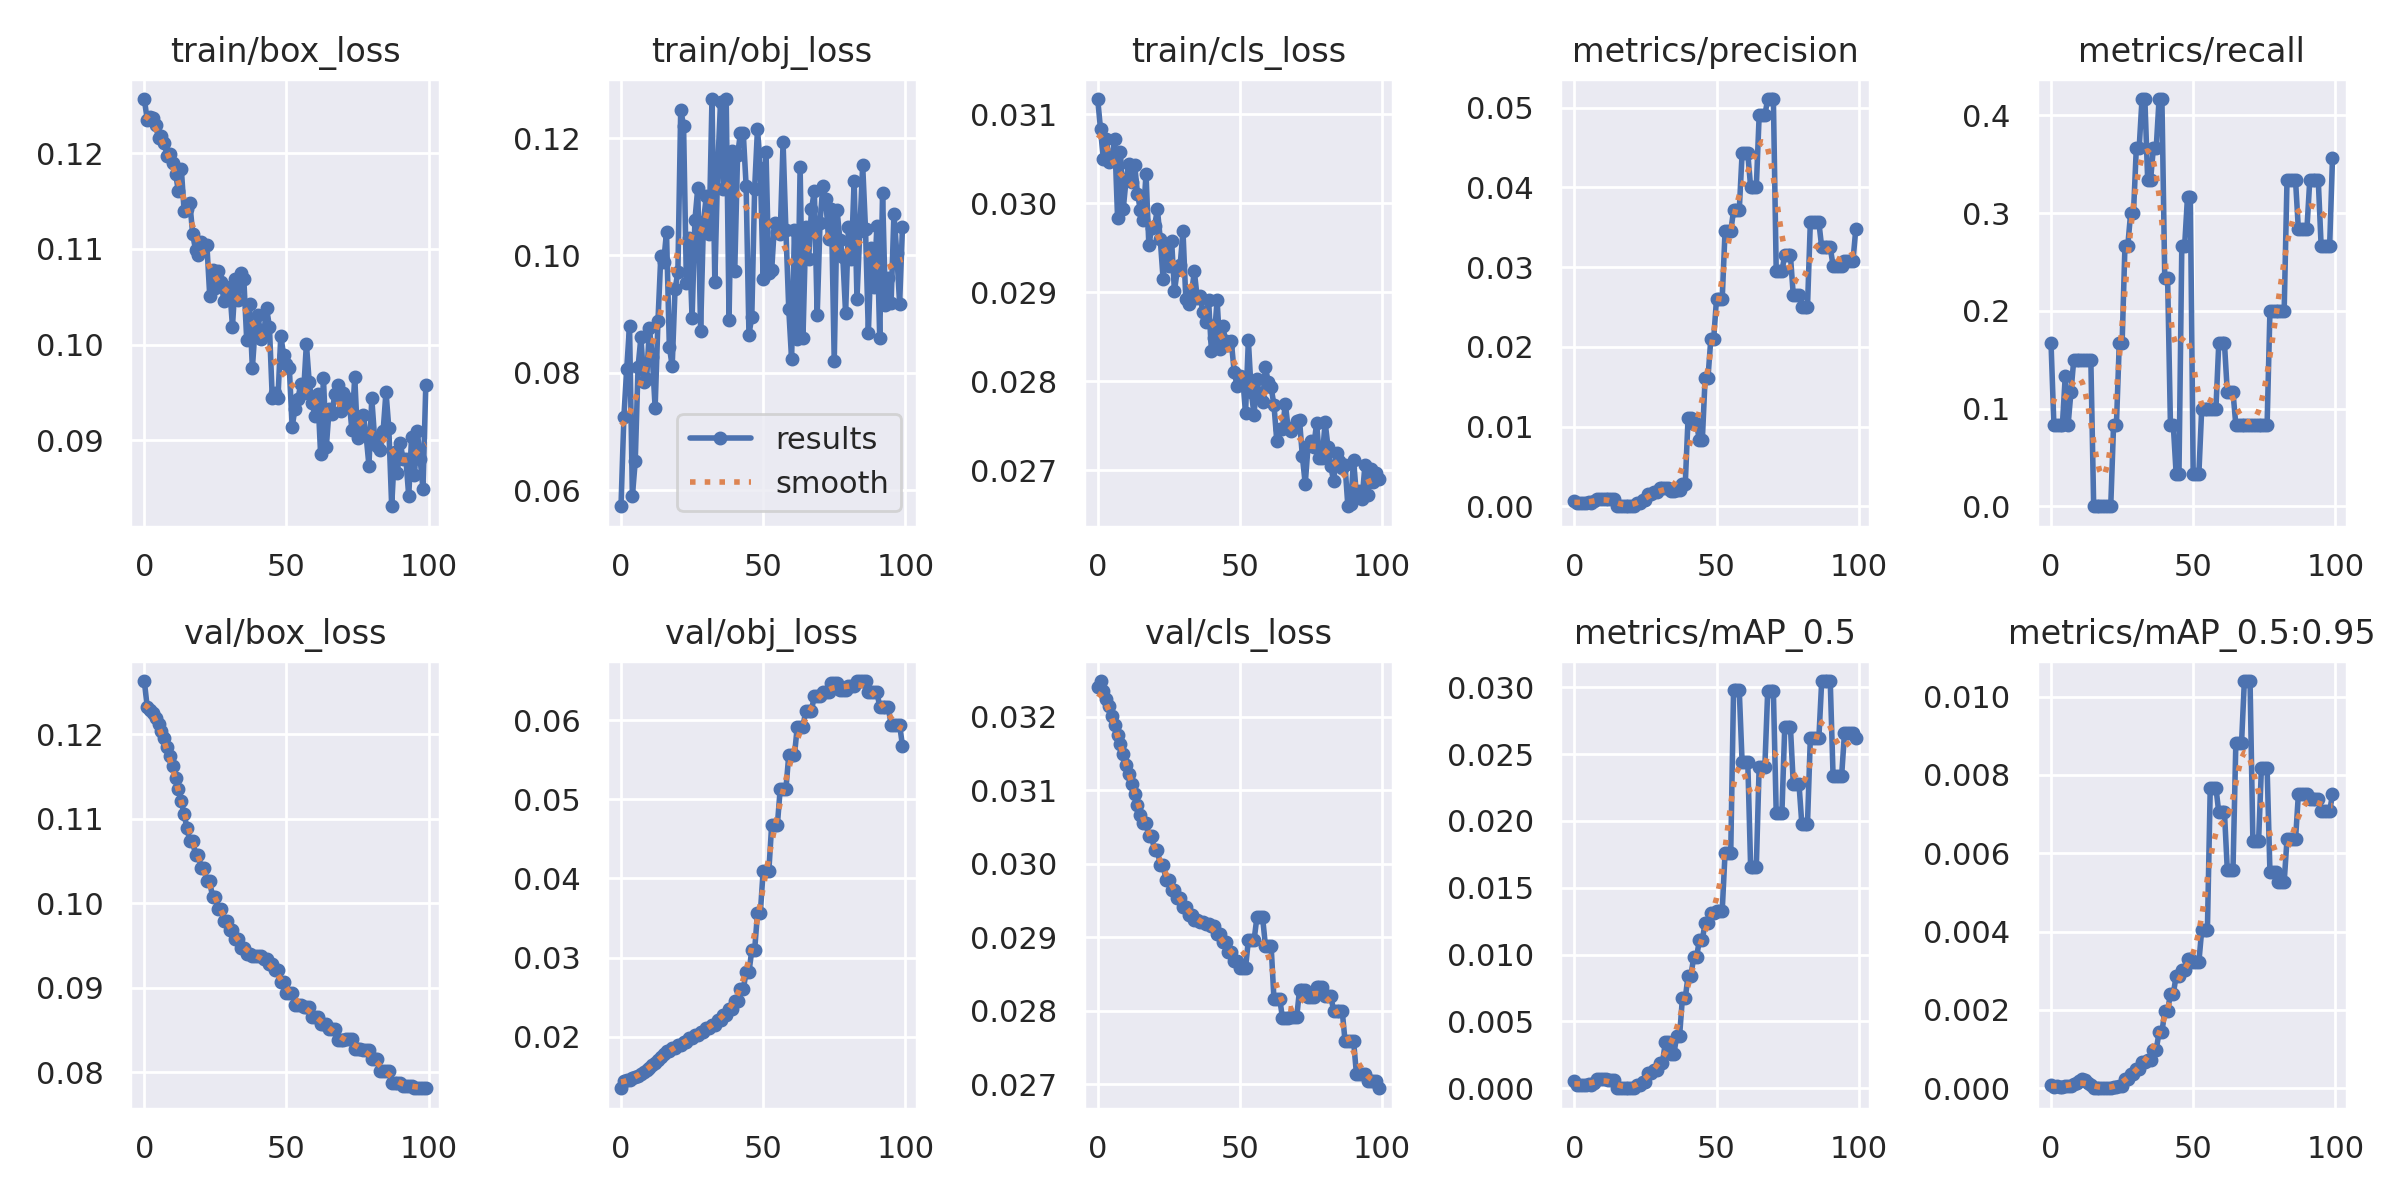

In [15]:
Image(filename='runs/train/exp/results.png', width=800)

In [ ]:
!pwd

/content/gdrive/MyDrive/Deep_Learning/Plants/Blur-Clear/yolov5


In [ ]:
!python detect.py --source runs/test_leaf.png --weights runs/train/exp/weights/best.pt --conf 0.25

detect: weights=['runs/train/exp/weights/best.pt'], source=runs/test_leaf.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-249-gf400bba Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/gdrive/MyDrive/Deep_Learning/Plants/Blur-Clear/yolov5/runs/test_leaf.png: 640x480 1 Blur, 1 Clear, 71.1ms
Speed: 0.7ms pre-process, 71.1ms inference, 6.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp


In [ ]:
Image(filename='runs/detect/exp/test_leaf.png', width=416)

Output hidden; open in https://colab.research.google.com to view.